[0.043082142857142854, 0.043132715450310555, 0.043183288043478256, 0.04323386063664596, 0.04328443322981366, 0.04333500582298136, 0.04338557841614907, 0.04343615100931677, 0.04348672360248447, 0.04353729619565217, 0.04358786878881987, 0.043638441381987574, 0.043689013975155275, 0.043739586568322976, 0.04379015916149068, 0.04384073175465838, 0.043891304347826086, 0.04394187694099379, 0.04399244953416149, 0.04404302212732919, 0.04409359472049689, 0.04414416731366459, 0.044194739906832294, 0.044245312499999995, 0.044295885093167696, 0.0443464576863354, 0.044397030279503105, 0.044447602872670806, 0.04449817546583851, 0.04454874805900621, 0.04459932065217391, 0.04464989324534161, 0.04470046583850931, 0.044751038431677014, 0.044801611024844715, 0.044852183618012416, 0.04490275621118012, 0.044953328804347825, 0.045003901397515526, 0.04505447399068323, 0.04510504658385093, 0.04515561917701863, 0.04520619177018633, 0.04525676436335403, 0.045307336956521733, 0.045357909549689435, 0.0454084821428

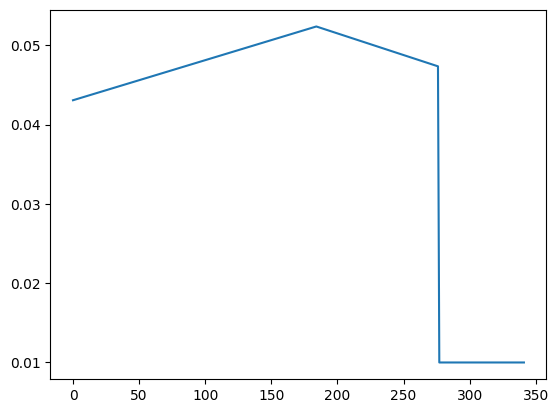

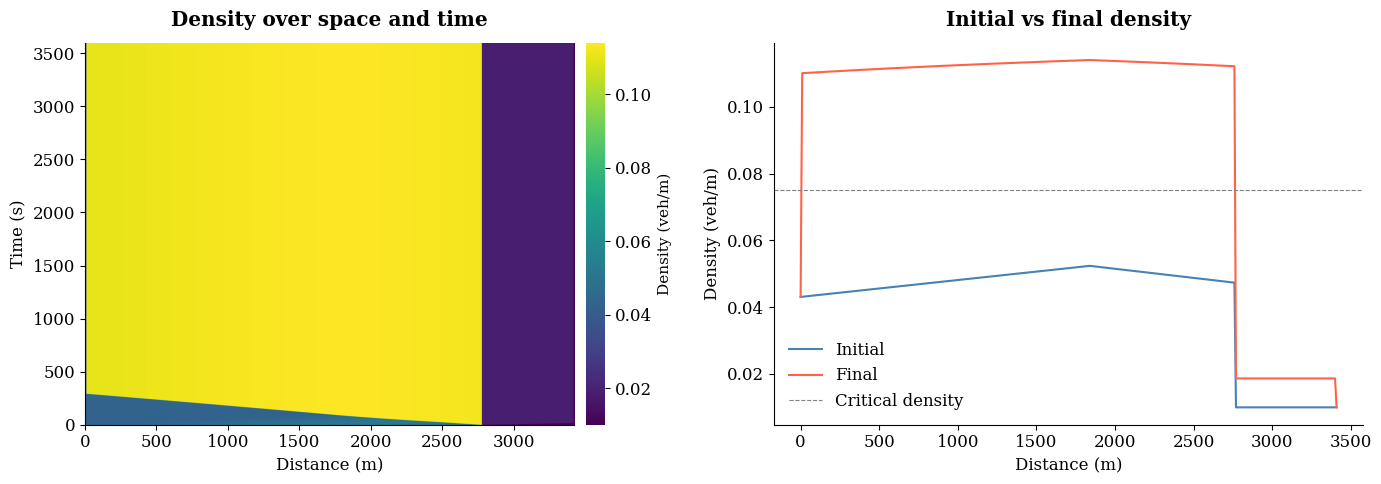

0 0
0 1
1 2
1 3
2 4
3 5
3 6
4 7
5 8
5 9
6 10
7 11
7 12
8 13
8 14
9 15
10 16
10 17
11 18
12 19
12 20
13 21
14 22
14 23
15 24
16 25
16 26
17 27
17 28
18 29
19 30
19 31
20 32
21 33
21 34
22 35
23 36
23 37
24 38
24 39
25 40
26 41
26 42
27 43
28 44
28 45
29 46
30 47
30 48
31 49
31 50
32 51
33 52
33 53
34 54
35 55
35 56
36 57
37 58
37 59
38 60
38 61
39 62
40 63
40 64
41 65
42 66
42 67
43 68
44 69
44 70
45 71
45 72
46 73
47 74
47 75
48 76
49 77
49 78
50 79
51 80
51 81
52 82
52 83
53 84
54 85
54 86
55 87
56 88
56 89
57 90
58 91
58 92
59 93
59 94
60 95
61 96
61 97
62 98
63 99
63 100
64 101
65 102
65 103
66 104
66 105
67 106
68 107
68 108
69 109
70 110
70 111
71 112
71 113
72 114
73 115
73 116
74 117
75 118
75 119
76 120
77 121
77 122
78 123
78 124
79 125
80 126
80 127
81 128
82 129
82 130
83 131
83 132
84 133
85 134
85 135
86 136
87 137
87 138
88 139
89 140
89 141
90 142
90 143
91 144
92 145
92 146
93 147
94 148
94 149
95 150
95 151
96 152
97 153
97 154
98 155
99 156
99 157
100 158
100 159
101 

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

# print("Python path:", sys.path)
# print("Parent folder contents:", os.listdir('..'))
# print("Current folder:", os.getcwd())

import inspect
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from src.lwr_model import point_density, number_of_cells, linear_density_gradient, clean_count_data
from src.lwr_model import FREE_SPEEDS, CELL_SIZE
from src.lwr_model.CTM import CTM_model

# --- Real world density ---
df_count = clean_count_data()
density_at_point = point_density(df_count)
cell_lengths = number_of_cells(density_at_point)
whole_density_arr = linear_density_gradient(density_at_point, cell_lengths)

# --- Model setup ---
density_init = np.clip(np.array(whole_density_arr), 0, 0.15 * 0.99)
N = len(density_init)
cell_widths = np.full(N, CELL_SIZE)

v_free = np.mean(list(FREE_SPEEDS.values()))
jam_density = 0.15
max_flow = v_free * jam_density / 4
inlet_density = density_init[0]
simulation_time = 60*60

# --- Run ---
model = CTM_model(cell_widths, density_init, jam_density, max_flow, v_free)
model.run(inlet_density=inlet_density, total_time=simulation_time)
print(whole_density_arr)
# --- Plot ---

plt.plot(whole_density_arr)

history = np.array(model.history)
distance = np.arange(N) * CELL_SIZE

mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
im = axes[0].imshow(
    history,
    aspect='auto',
    origin='lower',
    extent=[0, N * CELL_SIZE, 0, len(history) * model.step_width],
    cmap='viridis'
)
cbar = fig.colorbar(im, ax=axes[0], pad=0.02)
cbar.set_label('Density (veh/m)', fontsize=11)
cbar.outline.set_visible(False)
axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Density over space and time', fontweight='bold', pad=12)

# Initial vs final
axes[1].plot(distance, history[0], label='Initial', color='steelblue', linewidth=1.5)
axes[1].plot(distance, history[-1], label='Final', color='tomato', linewidth=1.5)
axes[1].axhline(jam_density / 2, color='grey', linestyle='--', linewidth=0.8, label='Critical density')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Density (veh/m)')
axes[1].set_title('Initial vs final density', fontweight='bold', pad=12)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

# --- Travel time ---
travel = model.travel_time(start_cell=0, end_cell=N-1, start_time=0)
print(N,CELL_SIZE)
print(f"Road length: {N * CELL_SIZE}m")
print(f"Travel time: {travel/60:.2f} min" if travel else "Vehicle did not reach end within simulation")